# Notebook 3 — Matplotlib & Seaborn for CA Professionals

**Goal:** Turn raw financial numbers into clean, presentable charts.

**You will learn:**
1. Why charts matter for reporting
2. Line charts (revenue trends)
3. Bar charts (department / city comparisons)
4. Pie chart (expense breakdown)
5. Histogram (distribution of invoice amounts)
6. Scatter plot (relationship between two columns)
7. Seaborn basics — prettier plots with one line
8. Box plot (spotting outliers)
9. Heatmap (correlation between metrics)
10. Saving a chart as an image
11. A short mini-project

---

## 1. Why visualise data?

A table of 200 invoices is overwhelming. A chart shows the story instantly — trends, outliers, top customers, seasonality. Auditors, managers and clients all understand a chart faster than a spreadsheet.

We will use **two libraries**:

| Library      | When to use it                                                  |
|--------------|-----------------------------------------------------------------|
| `matplotlib` | The foundation — full control, every kind of plot               |
| `seaborn`    | A friendly layer on top — prettier defaults, fewer lines of code|

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nicer default style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

print("ready")

ready


## 2. Line Chart — showing a trend over time

Best for **time series**: monthly revenue, daily price, quarterly profit.

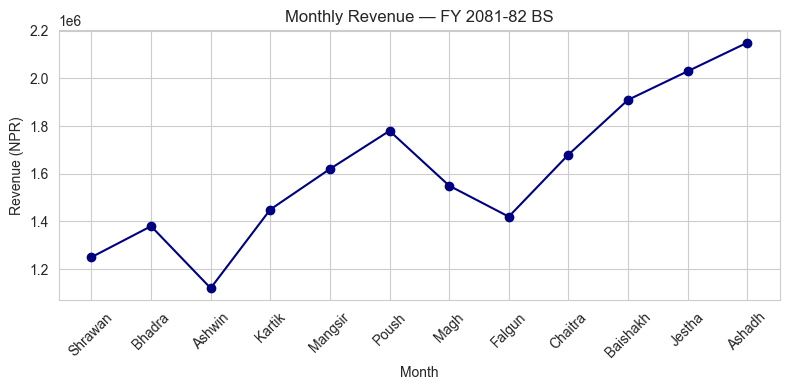

In [2]:
sales = pd.read_csv("data/monthly_sales.csv")

plt.plot(sales["Month"], sales["Revenue_NPR"], marker="o", color="navy")
plt.title("Monthly Revenue — FY 2081-82 BS")
plt.xlabel("Month")
plt.ylabel("Revenue (NPR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Practice 1
Make a line chart of `Expense_NPR` against `Month` from the same `sales` DataFrame. Use a different colour and add a title.

In [3]:
# Your turn:

<details><summary>Show solution</summary>

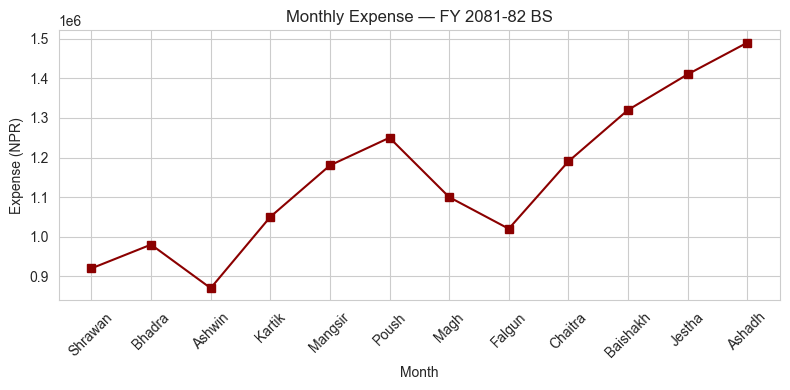

In [4]:
plt.plot(sales["Month"], sales["Expense_NPR"], marker="s", color="darkred")
plt.title("Monthly Expense — FY 2081-82 BS")
plt.xlabel("Month")
plt.ylabel("Expense (NPR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

</details>

## 3. Multiple lines on one chart

Just call `plt.plot()` twice (or more) before `plt.show()`.

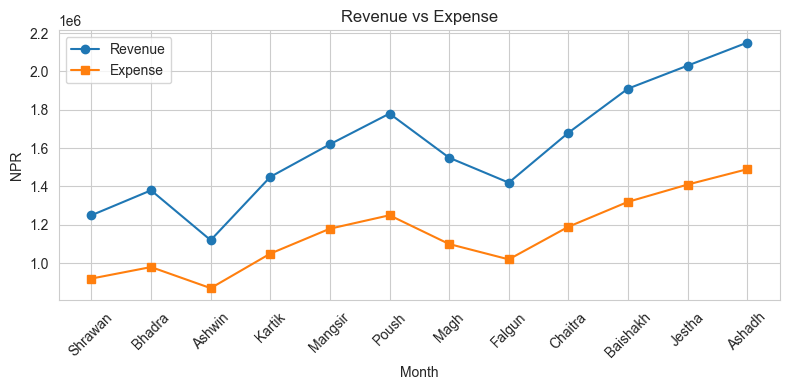

In [5]:
plt.plot(sales["Month"], sales["Revenue_NPR"], marker="o", label="Revenue")
plt.plot(sales["Month"], sales["Expense_NPR"], marker="s", label="Expense")
plt.title("Revenue vs Expense")
plt.xlabel("Month")
plt.ylabel("NPR")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Bar Chart — comparing categories

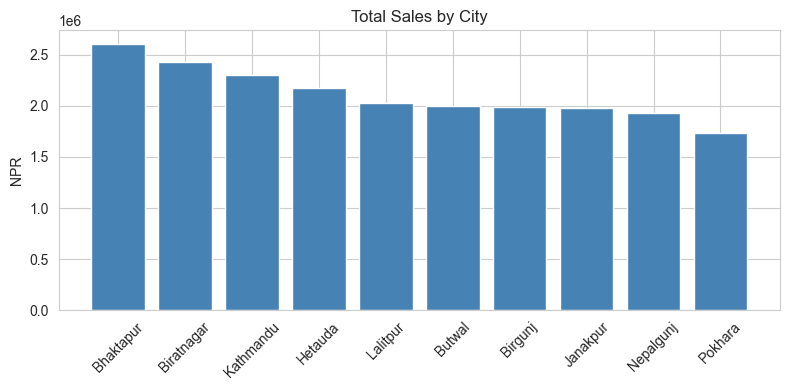

In [6]:
invoices = pd.read_csv("data/invoices.csv")

city_sales = invoices.groupby("City")["Total_NPR"].sum().sort_values(ascending=False)

plt.bar(city_sales.index, city_sales.values, color="steelblue")
plt.title("Total Sales by City")
plt.ylabel("NPR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Practice 2
Group `invoices` by `Product` (sum of `Amount_NPR`). Make a bar chart of the result.

In [7]:
# Your turn:

<details><summary>Show solution</summary>

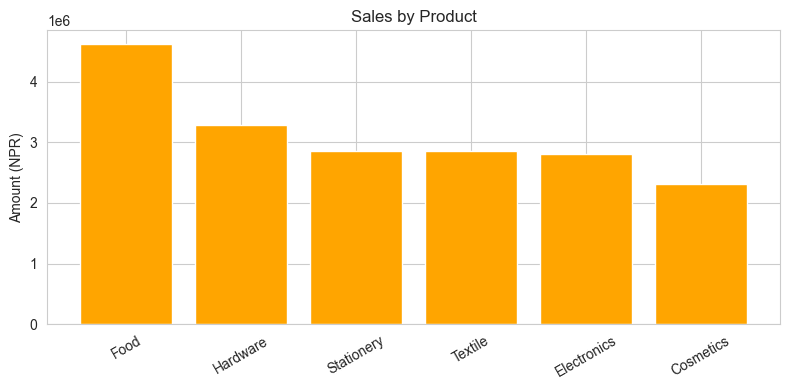

In [8]:
prod = invoices.groupby("Product")["Amount_NPR"].sum().sort_values(ascending=False)
plt.bar(prod.index, prod.values, color="orange")
plt.title("Sales by Product")
plt.ylabel("Amount (NPR)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

</details>

## 5. Pie Chart — share of the total

Pie charts are good when you want to show **how a total is split** into parts.

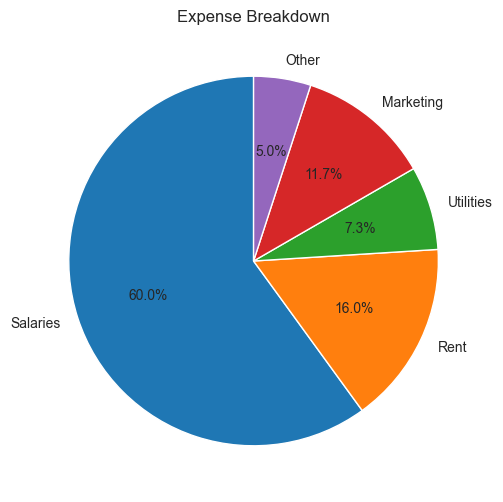

In [9]:
# Expense breakdown (made up example)
heads  = ["Salaries", "Rent", "Utilities", "Marketing", "Other"]
amounts = [1800000, 480000, 220000, 350000, 150000]

plt.figure(figsize=(6, 6))
plt.pie(amounts, labels=heads, autopct="%1.1f%%", startangle=90)
plt.title("Expense Breakdown")
plt.show()

### Practice 3
Group `invoices` by `Payment_Status` (count of invoices). Make a pie chart showing what % are Paid / Pending / Overdue.

In [10]:
# Your turn:

<details><summary>Show solution</summary>

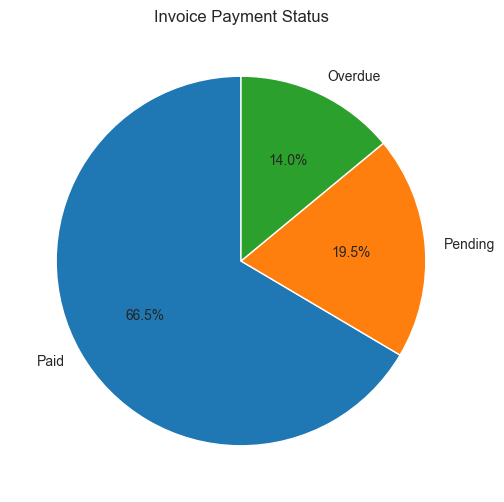

In [11]:
status = invoices["Payment_Status"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(status.values, labels=status.index, autopct="%1.1f%%", startangle=90)
plt.title("Invoice Payment Status")
plt.show()

</details>

## 6. Histogram — distribution of one column

Useful to see how amounts are spread: are most invoices small? Are salaries clustered?

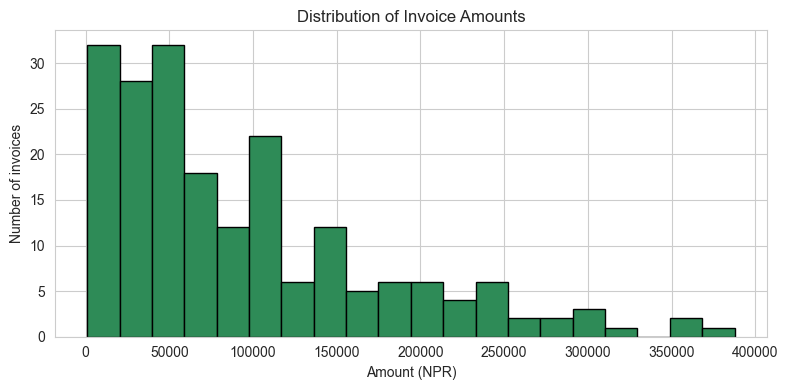

In [12]:
plt.hist(invoices["Amount_NPR"], bins=20, color="seagreen", edgecolor="black")
plt.title("Distribution of Invoice Amounts")
plt.xlabel("Amount (NPR)")
plt.ylabel("Number of invoices")
plt.tight_layout()
plt.show()

### Practice 4
Load `data/payroll.csv` and plot a histogram of `Net_Salary`.

In [13]:
# Your turn:

<details><summary>Show solution</summary>

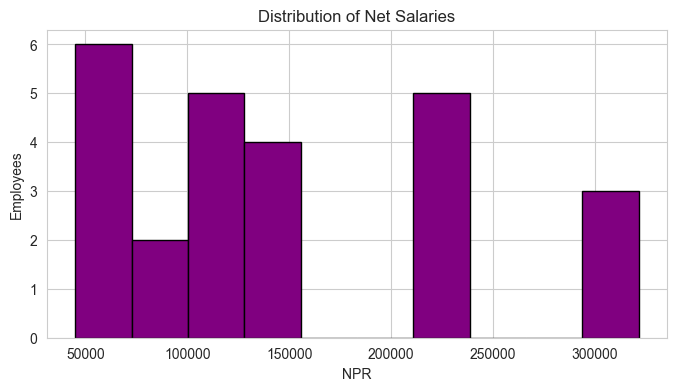

In [14]:
pay = pd.read_csv("data/payroll.csv")
plt.hist(pay["Net_Salary"], bins=10, color="purple", edgecolor="black")
plt.title("Distribution of Net Salaries")
plt.xlabel("NPR")
plt.ylabel("Employees")
plt.show()

</details>

## 7. Scatter Plot — relationship between two columns

Use this when you want to see: **does X go up when Y goes up?**

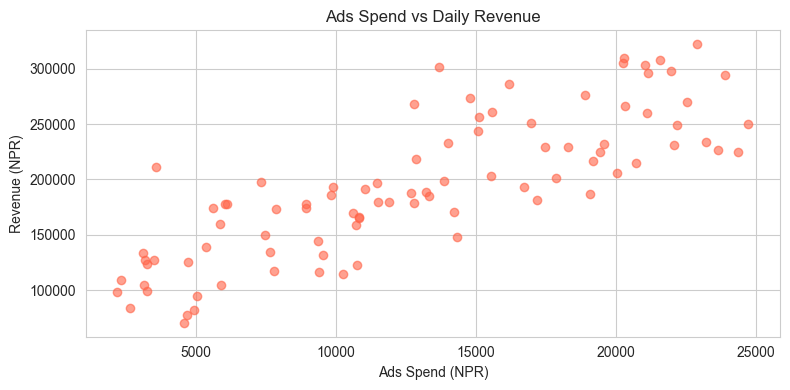

In [15]:
daily = pd.read_csv("data/daily_revenue.csv")

plt.scatter(daily["Ads_Spend"], daily["Revenue"], alpha=0.6, color="tomato")
plt.title("Ads Spend vs Daily Revenue")
plt.xlabel("Ads Spend (NPR)")
plt.ylabel("Revenue (NPR)")
plt.tight_layout()
plt.show()

### Practice 5
Make a scatter plot of `Footfall` (x-axis) vs `Revenue` (y-axis) from the `daily` DataFrame.

In [16]:
# Your turn:

<details><summary>Show solution</summary>

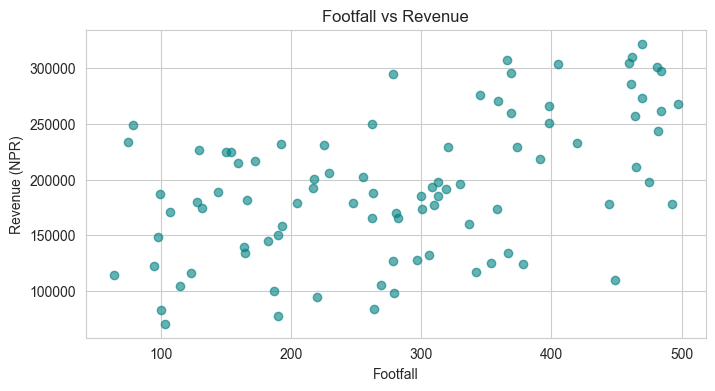

In [17]:
plt.scatter(daily["Footfall"], daily["Revenue"], alpha=0.6, color="teal")
plt.xlabel("Footfall")
plt.ylabel("Revenue (NPR)")
plt.title("Footfall vs Revenue")
plt.show()

</details>

## 8. Seaborn — same plots, simpler code

Seaborn is built on top of matplotlib. You pass it the DataFrame directly.

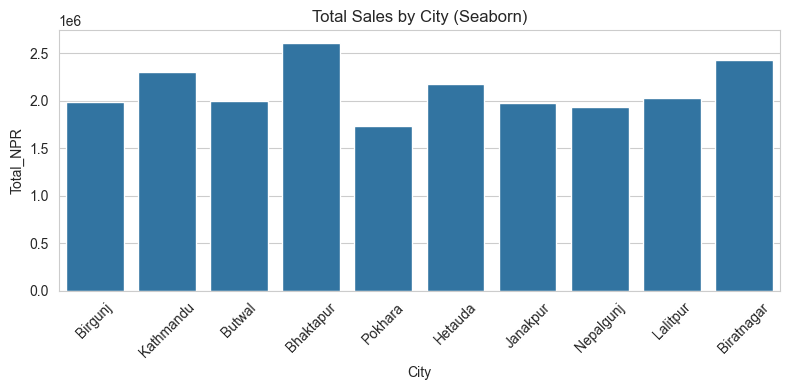

In [18]:
sns.barplot(data=invoices, x="City", y="Total_NPR", estimator=sum, errorbar=None)
plt.title("Total Sales by City (Seaborn)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

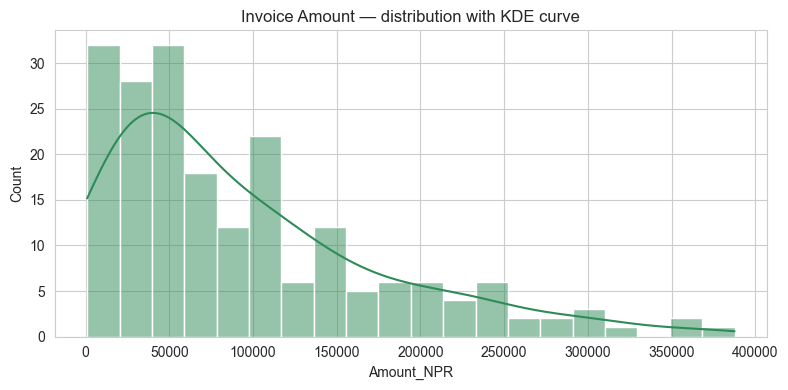

In [19]:
sns.histplot(data=invoices, x="Amount_NPR", bins=20, kde=True, color="seagreen")
plt.title("Invoice Amount — distribution with KDE curve")
plt.tight_layout()
plt.show()

## 9. Box Plot — spotting outliers

The box shows the middle 50% of data. The line in the middle is the median. Dots beyond the "whiskers" are **outliers** — unusually high or low values that may need investigation.

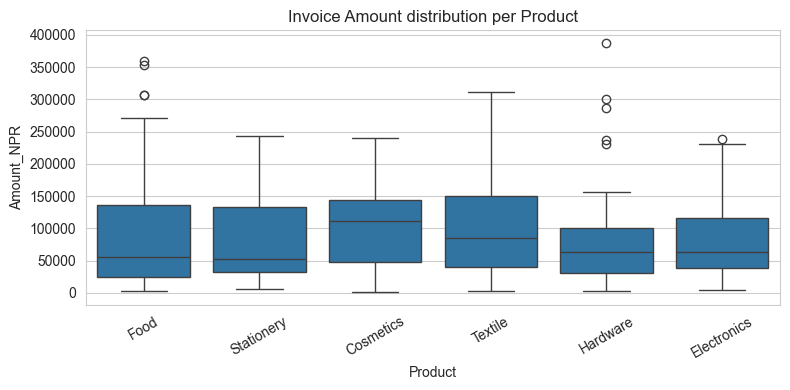

In [20]:
sns.boxplot(data=invoices, x="Product", y="Amount_NPR")
plt.title("Invoice Amount distribution per Product")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Practice 6
Make a box plot of `Net_Salary` (y-axis) per `Department` (x-axis), using the `pay` DataFrame.

In [21]:
# Your turn:

<details><summary>Show solution</summary>

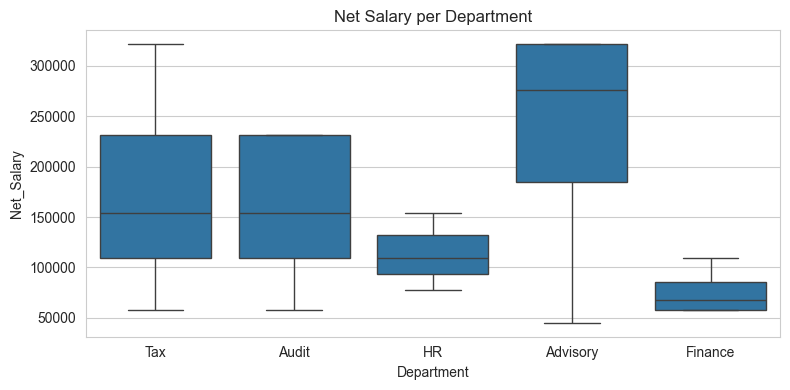

In [22]:
sns.boxplot(data=pay, x="Department", y="Net_Salary")
plt.title("Net Salary per Department")
plt.tight_layout()
plt.show()

</details>

## 10. Heatmap — correlation between numeric columns

A correlation heatmap shows how strongly two columns move together. Values close to **+1** mean they move together; close to **−1** mean opposite; close to **0** means no relationship.

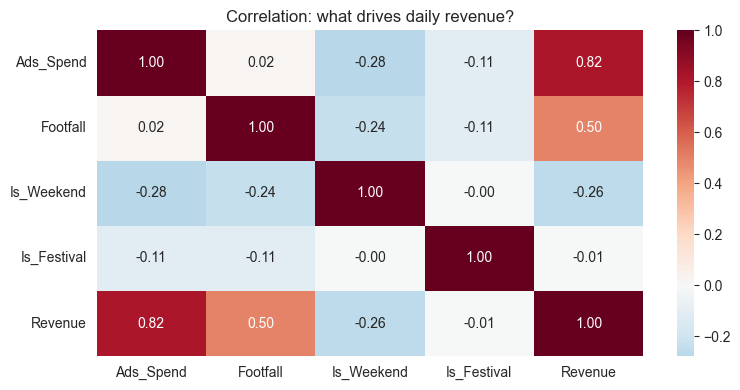

In [23]:
corr = daily[["Ads_Spend", "Footfall", "Is_Weekend", "Is_Festival", "Revenue"]].corr()
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Correlation: what drives daily revenue?")
plt.tight_layout()
plt.show()

## 11. Saving a chart to a file

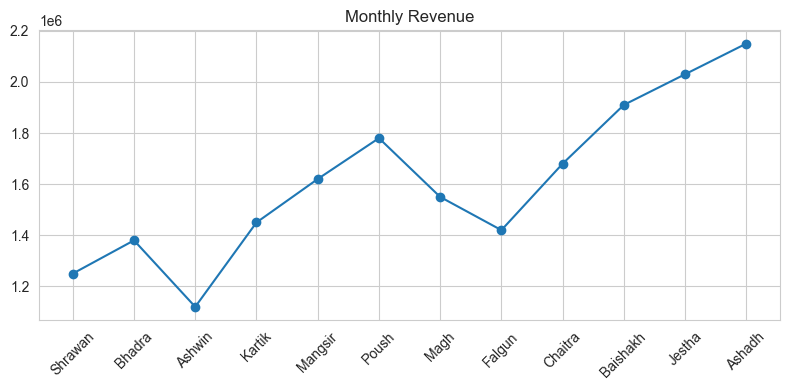

Saved revenue_chart.png


In [24]:
plt.plot(sales["Month"], sales["Revenue_NPR"], marker="o")
plt.title("Monthly Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("revenue_chart.png", dpi=150)   # ← saves to disk
plt.show()

print("Saved revenue_chart.png")

## 12. Mini-Project — Client-style Sales Dashboard

Using `data/invoices.csv` and `data/monthly_sales.csv`, make these 4 charts (one after another):

1. **Line chart** — monthly Revenue and Expense on one chart (with legend).
2. **Bar chart** — total `Total_NPR` per City (sorted, biggest first).
3. **Pie chart** — share of invoices by `Payment_Status`.
4. **Box plot** — `Amount_NPR` per `Product`.

In [25]:
inv = pd.read_csv("data/invoices.csv")
sl  = pd.read_csv("data/monthly_sales.csv")

# Your code here

<details><summary>Show solution</summary>

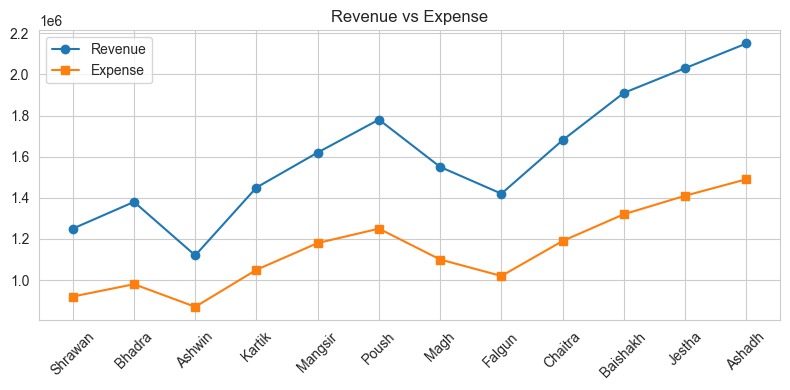

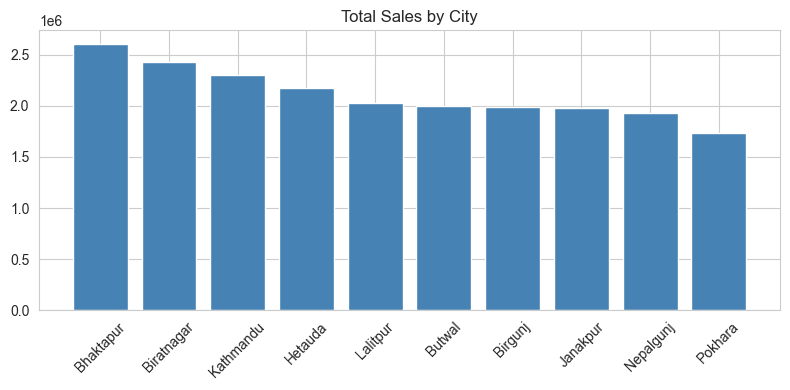

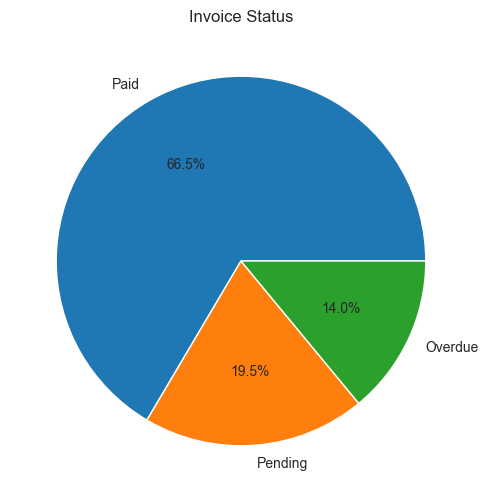

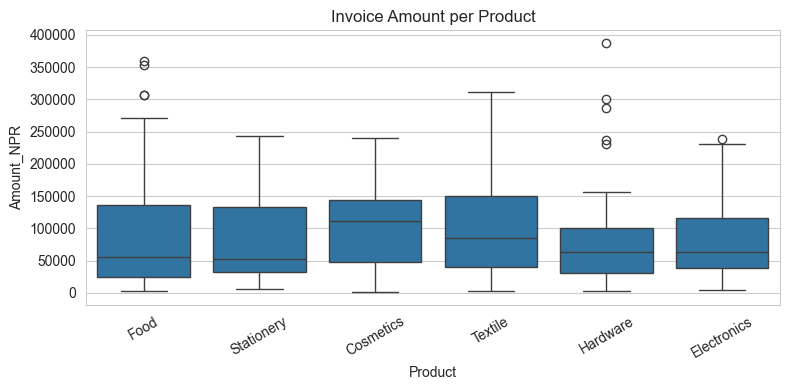

In [26]:
# 1. Line chart
plt.plot(sl["Month"], sl["Revenue_NPR"], marker="o", label="Revenue")
plt.plot(sl["Month"], sl["Expense_NPR"], marker="s", label="Expense")
plt.xticks(rotation=45); plt.legend(); plt.title("Revenue vs Expense")
plt.tight_layout(); plt.show()

# 2. Bar chart
city = inv.groupby("City")["Total_NPR"].sum().sort_values(ascending=False)
plt.bar(city.index, city.values, color="steelblue")
plt.xticks(rotation=45); plt.title("Total Sales by City")
plt.tight_layout(); plt.show()

# 3. Pie chart
st = inv["Payment_Status"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(st.values, labels=st.index, autopct="%1.1f%%")
plt.title("Invoice Status"); plt.show()

# 4. Box plot
sns.boxplot(data=inv, x="Product", y="Amount_NPR")
plt.xticks(rotation=30); plt.title("Invoice Amount per Product")
plt.tight_layout(); plt.show()

</details>

---
### What's next?
You can now communicate findings visually. Next we go back to data quality —
in `04_Data_Cleaning` we will learn how to **clean messy real-world data** before it can be plotted or modelled.